# 26. 고장 해석 (Model Interpretation)

목적: 학습된 앙상블 모델에 대해 SHAP 기반의 다층적 해석을 수행합니다.

| 섹션 | 내용 |
| --- | --- |
| **§9.1 전역적 해석 (Global)** | SHAP Summary Plot — 전체 데이터 기준 주요 고장 기여 피처 분석 |
| **§9.2 국소적 해석 (Local)** | SHAP Waterfall Plot — 특정 개체(시리얼)의 고장 예측 근거 설명 |
| **§9.3 시간 기반 해석 (Temporal)** | 고장 전 N일 창에서의 SHAP 기여도 변화 trajectory 추적 |

> ⚠️ 사전 조건: `07_threshold_tuning.ipynb` 및 `08_final_evaluation.ipynb` 실행 완료 후 진행하세요.

## 0. 환경 준비

In [7]:
import sys, os, json, joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

sys.path.insert(0, os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

import config.interp_config as cfg
import config.train_config as tcfg
import config.final_eval_config as fe_cfg
from src.eval_core import prepare_disk_level_data, get_detailed_disk_records

warnings.filterwarnings("ignore")

# 한글 폰트 설정
for _font in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
    if any(_font.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

print("✅ 환경 준비 완료")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ 환경 준비 완료


## 1. 모델 및 데이터 로드

In [9]:
from pathlib import Path

SAVE_DIR = Path(tcfg.MODEL_SAVE_DIR)

# ── 피처 목록 로드 ─────────────────────────────────────────
with open(SAVE_DIR / "feature_cols.json", encoding="utf-8") as f:
    FEATURE_COLS = json.load(f)

# ── 앙상블 모델 로드 ───────────────────────────────────────
models = [joblib.load(p) for p in sorted(SAVE_DIR.glob("subset_*.pkl"))]

# ── 최적 임계값 로드 (final_eval_config 에서 가져옴) ─────────
# 수동 오버라이드 (config에 설정된 경우 우선 적용)
BEST_T = getattr(fe_cfg, "MANUAL_BEST_T", None)
BEST_N = getattr(fe_cfg, "MANUAL_BEST_N", None)
if BEST_T is None or BEST_N is None:
    with open(SAVE_DIR / "best_threshold.json", encoding="utf-8") as f:
        th_data = json.load(f)
        if BEST_T is None: BEST_T = th_data["threshold"]
        if BEST_N is None: BEST_N = th_data["min_alarms"]
ALARM_WINDOW = getattr(fe_cfg, "ALARM_WINDOW", 14)

# ── 테스트 데이터 로드 (고장 당일 포함본) ───────────────────
# interp_config 대신 최신 데이터가 반영된 final_eval_config의 경로 사용
test_path = Path(fe_cfg.TEST_PATH)
df_test = pd.read_parquet(test_path)
df_test[cfg.DATE_COL] = pd.to_datetime(df_test[cfg.DATE_COL])

# ── 앙상블 예측 (캐시 활용) ─────────────────────────────────
cache_filename = f"{test_path.stem}_probs.npy"
cache_path = SAVE_DIR / cache_filename

if os.path.exists(cache_path):
    print(f"♻️ 캐시 로드 중: {cache_filename}")
    y_prob = np.load(cache_path)
    if len(y_prob) != len(df_test):
        print("⚠️ 데이터 크기 불일치. 재예측 수행...")
        y_prob = np.mean([m.predict_proba(df_test[FEATURE_COLS])[:, 1] for m in models], axis=0)
        np.save(cache_path, y_prob)
else:
    print(f"🔄 앙상블 추론 중... (모델 {len(models)}개 × 데이터 {len(df_test):,}행)")
    y_prob = np.mean([m.predict_proba(df_test[FEATURE_COLS])[:, 1] for m in models], axis=0)
    np.save(cache_path, y_prob)

df_test["_prob"]  = y_prob

print(f"✅ 로드 완료: 피처 {len(FEATURE_COLS)}개 | 운영점 T={BEST_T:.4f}, n={BEST_N} (W={ALARM_WINDOW})")
print(f"   테스트 데이터: {len(df_test):,}행 | 고장행: {df_test[cfg.TARGET_COL].sum():,}")

# ── 실제 디스크 단위 알람 이력 추출 (n회 연속 조건 반영) ──────
disks_data, n_fail, n_norm = prepare_disk_level_data(df_test, y_prob)
df_best_disk = get_detailed_disk_records(disks_data, BEST_T, BEST_N, window_size=ALARM_WINDOW)
# _alarm 컬럼을 단순 확률(1회)가 아니라 n회 조건 만족 여부로 생성하기 위해 
# 원래 df_test 에 매핑하기는 복잡하므로 df_best_disk 정보를 활용합니다.


♻️ 캐시 로드 중: test_with_failure_date_probs.npy
✅ 로드 완료: 피처 27개 | 운영점 T=0.9261, n=2 (W=14)
   테스트 데이터: 15,696,223행 | 고장행: 12,256


---
## §9.1 전역적 해석 (Global Interpretability)

SHAP Summary Plot을 통해 전체 테스트 데이터에서 어떤 피처가 고장 예측에 얼마나, 어떤 방향으로 기여하는지 분석합니다.

- 앙상블 모델 전체의 평균 SHAP 값을 사용
- **x축:** 개별 예측에 대한 SHAP 값 (양수 = 고장 확률 증가에 기여)
- **색상:** 해당 피처의 원본 값 수준 (붉을수록 높은 값)

In [ ]:
import shap

# SHAP 계산용 5:5 균형 추출 (고장 패턴을 전역 해석에서 뚜렷하게 보기 위함)
sample_size = min(cfg.SHAP_SAMPLE_SIZE, len(df_test))
target_fail_count = sample_size // 2

# 1. 고장/정상 인덱스 분리
fail_indices = df_test[df_test[cfg.TARGET_COL] == 1].index
norm_indices = df_test[df_test[cfg.TARGET_COL] == 0].index

# 2. 고장 데이터 샘플링 (전체 샘플의 절반을 목표로 하되, 모자라면 전수 사용)
n_fail_sample = min(len(fail_indices), target_fail_count)
# 나머지를 정상 데이터로 채움
n_norm_sample = sample_size - n_fail_sample

fail_sample = df_test.loc[fail_indices].sample(n_fail_sample, random_state=cfg.SHAP_SEED)
norm_sample = df_test.loc[norm_indices].sample(n_norm_sample, random_state=cfg.SHAP_SEED)

# 3. 데이터셋 결합 및 셔플 (순서가 뭉치지 않게)
df_sample = pd.concat([fail_sample, norm_sample]).sample(frac=1, random_state=cfg.SHAP_SEED).reset_index(drop=True)

X_sample = df_sample[FEATURE_COLS]
y_sample = df_sample[cfg.TARGET_COL]

print(f"SHAP 계산 중... (샘플={sample_size:,}, 모델={len(models)}개)")
print(f"  → 균형 튜닝 추출 완료: 고장 {n_fail_sample:,}개 / 정상 {n_norm_sample:,}개")
print("  ※ 모델 수 × 샘플 수에 비례하여 수 분 소요될 수 있습니다.")

sv_list = []
for i, model in enumerate(models):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_sample)
    if isinstance(sv, list):
        sv = sv[1]  # 이진 분류: 양성 클래스(고장) SHAP
    sv_list.append(sv)
    print(f"  모델 {i+1}/{len(models)} 완료", end="\r")

mean_shap = np.mean(sv_list, axis=0)
print(f"\n✅  SHAP 계산 완료!")


SHAP 계산 중... (샘플=2,000, 모델=10개)
  → 추출된 샘플 내 고장 행 수: 2개
  ※ 모델 수 × 샘플 수에 비례하여 수 분 소요될 수 있습니다.


In [ ]:
# §9.1 Summary Plot (Beeswarm)
print("[§9.1] SHAP Summary Plot (전역 해석)")
shap.summary_plot(
    mean_shap,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=cfg.SHAP_MAX_DISPLAY,
    show=True,
    plot_size=(10, 8),
)

In [ ]:
# §9.1 Bar Plot — 절댓값 평균 기준 피처 중요도
print("[§9.1] SHAP Bar Plot (Mean |SHAP| 기준 피처 중요도)")
shap.summary_plot(
    mean_shap,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=cfg.SHAP_MAX_DISPLAY,
    plot_type="bar",
    show=True,
    plot_size=(10, 8),
)

# 중요도 순위 테이블 출력
mean_abs_shap = np.abs(mean_shap).mean(axis=0)
shap_rank_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
shap_rank_df.index += 1
print("\n📊 피처 중요도 순위 (Mean |SHAP|):")
print(shap_rank_df.to_markdown())

---
## §9.2 국소적 해석 (Local Interpretability)

특정 개체(시리얼 번호)에 대해 SHAP Waterfall Plot을 통해 고장 예측의 근거를 설명합니다.

- 고장이 났으나 탐지하지 못한 **미탐 개체** 또는 **탐지 성공 개체**를 선택하여 분석
- 어떤 피처가 어느 방향으로 고장 확률을 끌어올리거나 낮췄는지 확인 가능

In [20]:
# 분석 대상 시리얼 선택 (비교 분석을 위해 다중 타겟 지원)
target_serials = []
if cfg.TARGET_SERIAL is not None:
    target_serials.append(cfg.TARGET_SERIAL)
    print(f"[수동 지정] 분석 대상: {target_serials[0]}")
else:
    hit_disks = df_best_disk[(df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1)]
    miss_disks = df_best_disk[(df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)]
    fa_disks = df_best_disk[(df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 1)]
    
    selected_types = []
    if len(hit_disks) > 0:
        target_serials.append(hit_disks.sample(1, random_state=cfg.SHAP_SEED).iloc[0]['base_serial'])
        selected_types.append("Hit(탐지 성공)")
    if len(miss_disks) > 0:
        target_serials.append(miss_disks.sample(1, random_state=cfg.SHAP_SEED).iloc[0]['base_serial'])
        selected_types.append("Miss(미탐)")
        
    if len(fa_disks) > 0:
        # 🌟 단순 라벨상 오탐이 아니라, '알람 발령 후 30일 이상 멀쩡히 살아남은 진짜 오탐' 개체 필터링
        real_fa_serial = None
        for s in fa_disks.sample(frac=1, random_state=cfg.SHAP_SEED)['base_serial']:
            df_s = df_test[df_test[cfg.SERIAL_COL] == s]
            alarms = (df_s['_prob'] >= BEST_T).astype(int)
            rolling = alarms.rolling(window=ALARM_WINDOW, min_periods=1).sum()
            idx = np.where(rolling >= BEST_N)[0]
            if len(idx) > 0:
                first_alarm = df_s[cfg.DATE_COL].iloc[idx[0]]
                last_obs = df_s[cfg.DATE_COL].max()
                if (last_obs - first_alarm).days >= 30:
                    real_fa_serial = s
                    break
                    
        if real_fa_serial is not None:
            target_serials.append(real_fa_serial)
            selected_types.append("FA(진짜 오탐)")
        else:
            target_serials.append(fa_disks.sample(1, random_state=cfg.SHAP_SEED).iloc[0]['base_serial'])
            selected_types.append("FA(오탐)")
        
    print(f"[자동 선택] 비교 분석을 위해 {', '.join(selected_types)} 개체를 각각 1개씩 추출했습니다.")

def print_lifecycle(serial_num, disk_info):
    df_entity = df_test[df_test[cfg.SERIAL_COL] == serial_num].sort_values(cfg.DATE_COL)
    first_obs = df_entity[cfg.DATE_COL].min().date()
    last_obs = df_entity[cfg.DATE_COL].max().date()
    
    print(f"\n  [개체 생애 (Lifecycle) 요약: {serial_num}]")
    print(f"  - 데이터 수집 기간 : {first_obs} ~ {last_obs} (총 {len(df_entity)}일간 관측)")
    
    raw_alarms = df_entity[df_entity['_prob'] >= BEST_T]
    
    if disk_info['is_alarmed'] == 1:
        if disk_info['is_failed'] == 1:
            first_alarm = last_obs - pd.Timedelta(days=disk_info['lead_time']) if not np.isnan(disk_info['lead_time']) else "해당 없음"
            print(f"  - 시스템 최종 확정 : {first_alarm} (고장 {disk_info['lead_time']}일 전 감지)")
        else:
            alarms = (df_entity['_prob'] >= BEST_T).astype(int)
            rolling = alarms.rolling(window=ALARM_WINDOW, min_periods=1).sum()
            idx = np.where(rolling >= BEST_N)[0]
            first_alarm_date = df_entity[cfg.DATE_COL].iloc[idx[0]].date() if len(idx) > 0 else "N/A"
            days_before = (last_obs - first_alarm_date).days if len(idx) > 0 else "N/A"
            print(f"  - 시스템 최종 확정 : {first_alarm_date} (관측 종료일로부터 {days_before}일 전에 오탐 발령됨)")
    else:
        print(f"  - 시스템 최종 확정 : 없음 (경보 미발령)")
        
    if len(raw_alarms) > 0:
        alarm_details = []
        for d in raw_alarms[cfg.DATE_COL].dt.date.values:
            days_before = (last_obs - d).days
            alarm_details.append(f"D-{days_before}")
        print(f"  - 모델 단일 경고 이력: 총 {len(raw_alarms)}회 ({', '.join(alarm_details)})")
    else:
        print(f"  - 모델 단일 경고 이력: 없음")
        
    if disk_info['is_failed'] == 1:
        status = '✅ 탐지 성공 (Hit)' if disk_info['is_alarmed'] else '❌ 미탐 (Miss)'
        fail_text = '고장'
    else:
        status = '❌ 오탐 (False Alarm)' if disk_info['is_alarmed'] else '✅ 정상 정탐 (True Negative)'
        fail_text = '정상'
        
    print(f"  - 최종 평가 결과   : {status} ({fail_text} 디스크)\n")

for serial in target_serials:
    info = df_best_disk[df_best_disk['base_serial'] == serial].iloc[0]
    print("="*60)
    print_lifecycle(serial, info)


[자동 선택] 비교 분석을 위해 Hit(탐지 성공), Miss(미탐), FA(진짜 오탐) 개체를 각각 1개씩 추출했습니다.

  [개체 생애 (Lifecycle) 요약: S301KX66]
  - 데이터 수집 기간 : 2015-11-05 ~ 2016-06-13 (총 222일간 관측)
  - 시스템 최종 확정 : 2016-06-10 (고장 3.0일 전 감지)
  - 모델 단일 경고 이력: 없음
  - 최종 평가 결과   : ✅ 탐지 성공 (Hit) (고장 디스크)


  [개체 생애 (Lifecycle) 요약: Z305DTQS]
  - 데이터 수집 기간 : 2016-02-09 ~ 2017-01-17 (총 344일간 관측)
  - 시스템 최종 확정 : 없음 (경보 미발령)
  - 모델 단일 경고 이력: 없음
  - 최종 평가 결과   : ❌ 미탐 (Miss) (고장 디스크)


  [개체 생애 (Lifecycle) 요약: S300ZNVD]
  - 데이터 수집 기간 : 2015-07-29 ~ 2017-01-17 (총 539일간 관측)
  - 시스템 최종 확정 : 2015-10-15 (관측 종료일로부터 460일 전에 오탐 발령됨)
  - 모델 단일 경고 이력: 총 3회 (D-461, D-460, D-459)
  - 최종 평가 결과   : ❌ 오탐 (False Alarm) (정상 디스크)




[§9.2] Waterfall Plot — 개체: S301KX66
       최고 위험 시점: 2015-11-05 (예측 확률=0.1922)


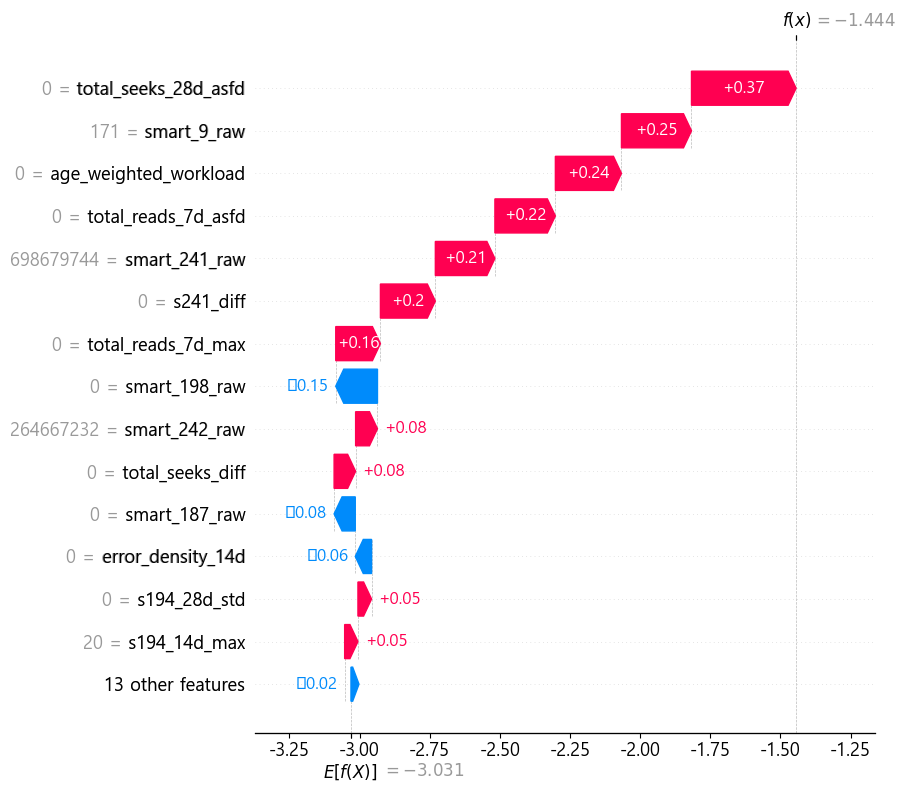


[§9.2] Waterfall Plot — 개체: Z305DTQS
       최고 위험 시점: 2016-07-23 (예측 확률=0.1264)


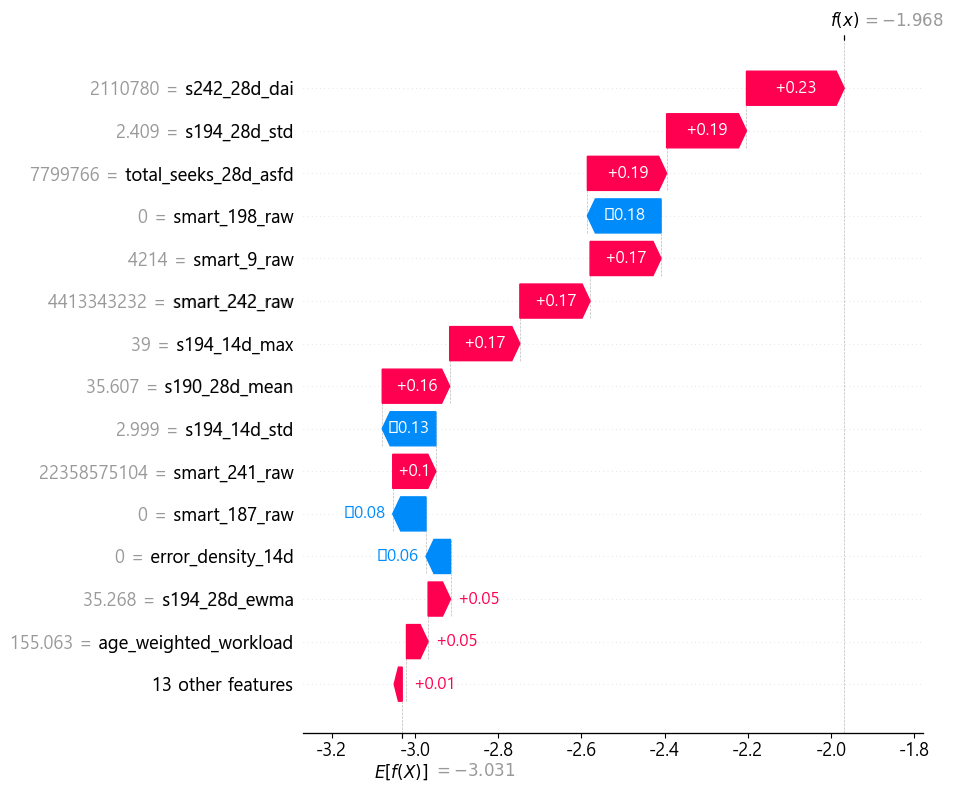


[§9.2] Waterfall Plot — 개체: S300ZNVD
       최고 위험 시점: 2015-10-14 (예측 확률=0.9457)


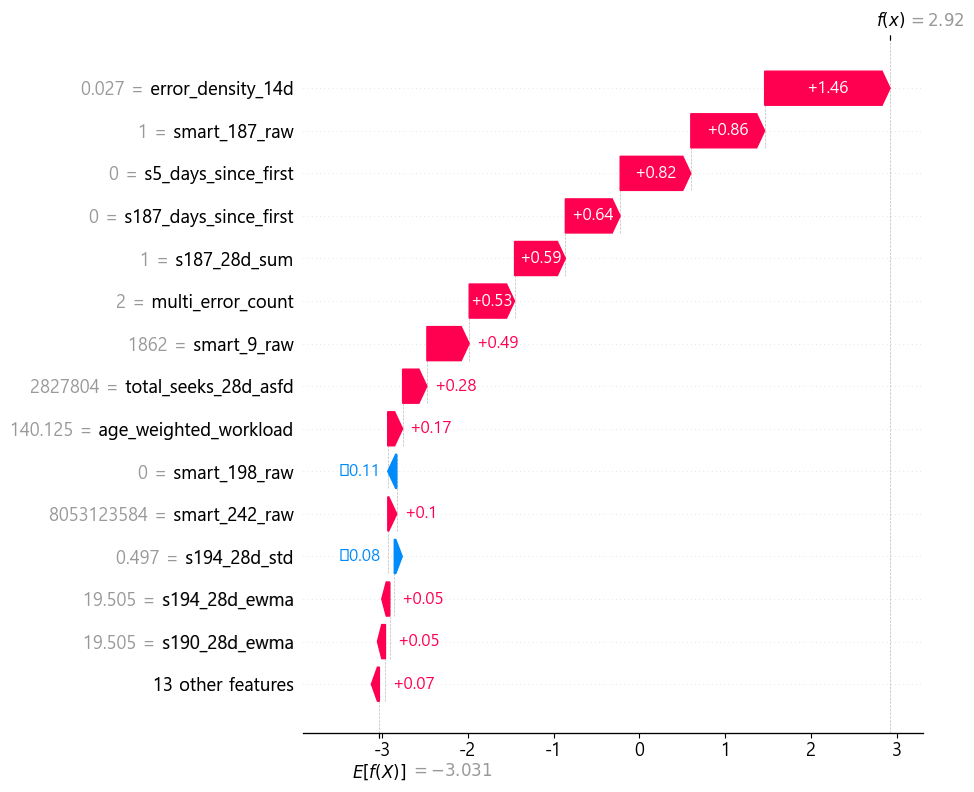

In [21]:
# §9.2 Waterfall Plot — 고장 확률이 가장 높은 시점 (각 개체별)
for serial in target_serials:
    df_entity = df_test[df_test[cfg.SERIAL_COL] == serial].sort_values(cfg.DATE_COL)
    X_entity = df_entity[FEATURE_COLS].reset_index(drop=True)

    # 앙상블 전체의 SHAP 평균 계산
    sv_entity_list = []
    for model in models:
        exp = shap.TreeExplainer(model)
        sv_e = exp.shap_values(X_entity)
        if isinstance(sv_e, list):
            sv_e = sv_e[1]
        sv_entity_list.append(sv_e)
    mean_sv_entity = np.mean(sv_entity_list, axis=0)

    # 고장 확률이 가장 높은 시점 선택
    peak_idx = df_entity["_prob"].values.argmax()
    peak_date = df_entity[cfg.DATE_COL].iloc[peak_idx].date()
    peak_prob = df_entity["_prob"].iloc[peak_idx]
    
    print(f"\n" + "="*70)
    print(f"[§9.2] Waterfall Plot — 개체: {serial}")
    print(f"       최고 위험 시점: {peak_date} (예측 확률={peak_prob:.4f})")
    print("="*70)

    # 첫 번째 모델 기준 expected_value 사용
    base_vals = np.mean([shap.TreeExplainer(m).expected_value for m in models])
    if isinstance(base_vals, np.ndarray):
        base_vals = base_vals[1]

    explanation = shap.Explanation(
        values=mean_sv_entity[peak_idx],
        base_values=float(base_vals),
        data=X_entity.iloc[peak_idx].values,
        feature_names=FEATURE_COLS,
    )

    shap.plots.waterfall(explanation, max_display=15, show=True)


---
## §9.3 시간 기반 해석 (Temporal Interpretation)

고장은 하루아침에 발생하지 않고 점진적으로 열화됩니다.  
고장 전 **`TEMPORAL_WINDOW_DAYS`일** 동안 각 피처의 SHAP 기여도가 어떻게 변화했는지 추적합니다.

- **x축:** 고장 직전 경과일 (D-N → D-1 방향으로 진행)
- **y축:** 해당 피처의 SHAP 값 (양수 = 고장 확률 증가 기여)



[§9.3] 시간 기반 SHAP Trajectory — 개체: S301KX66
       분석 기간: 2016-05-15 ~ 2016-06-13 (30일)


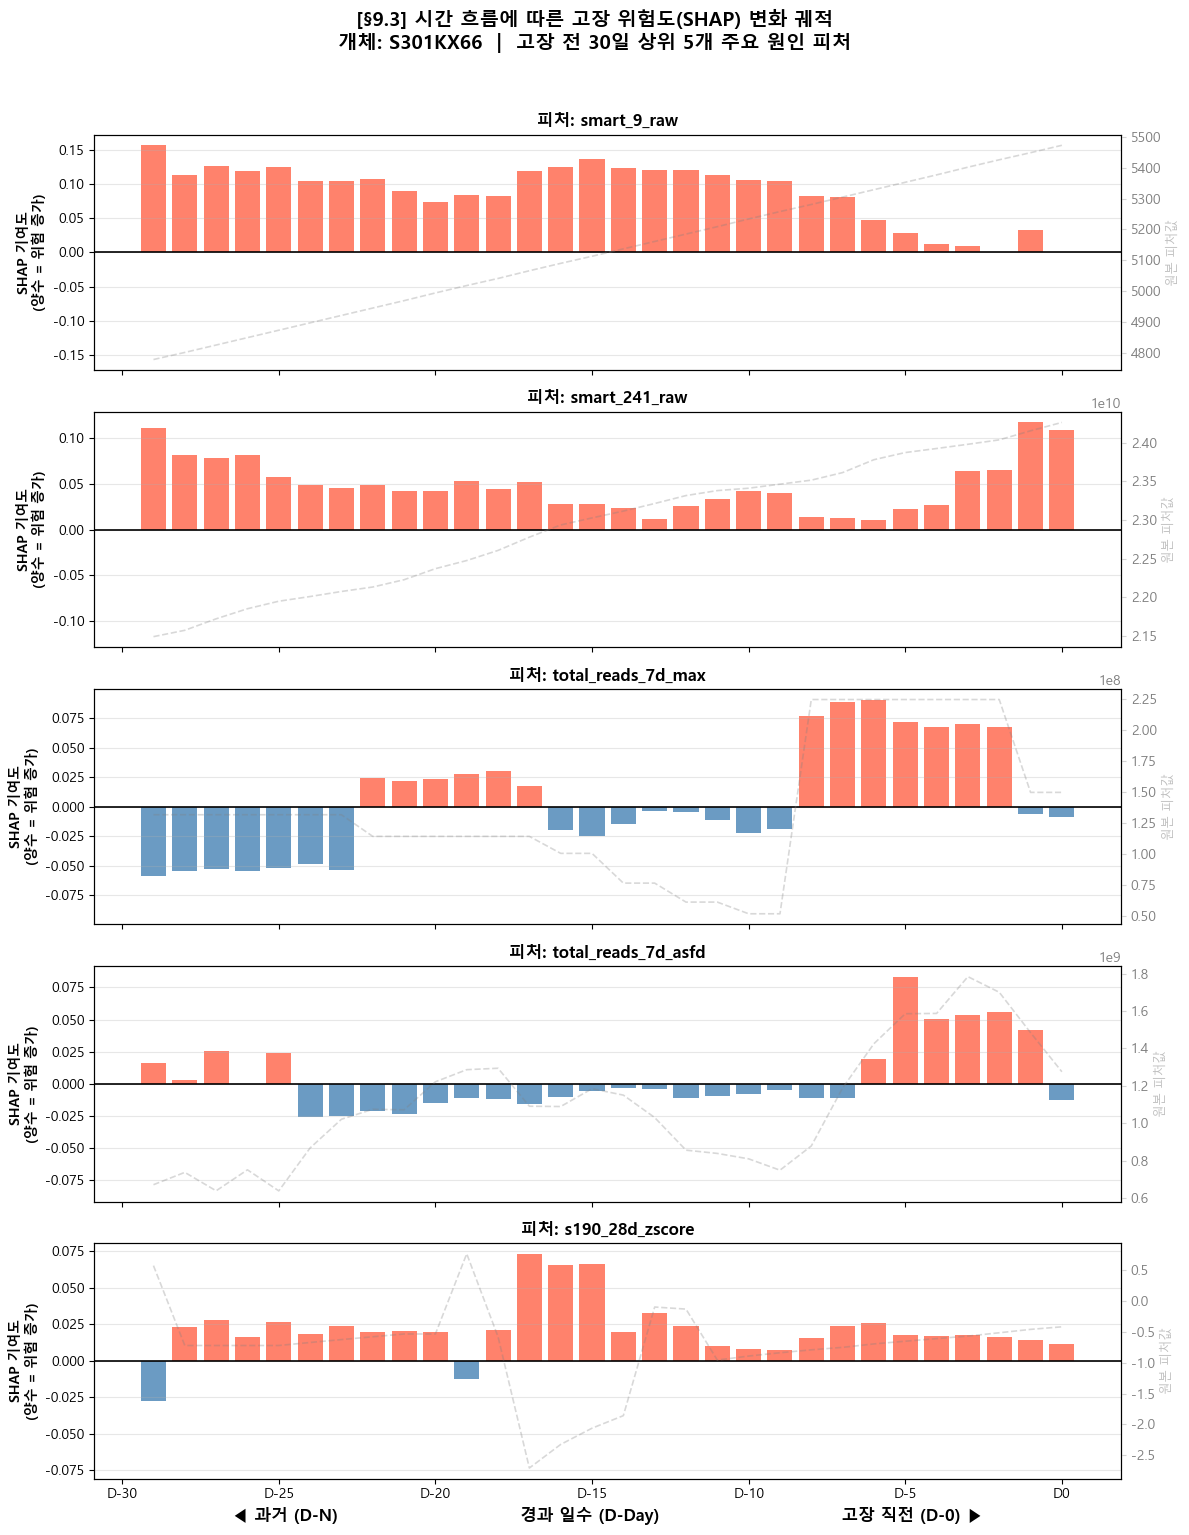


개체 S301KX66 분석 완료. 고장 위험을 가장 크게 높인 상위 5개 피처: ['smart_9_raw', 'smart_241_raw', 'total_reads_7d_max', 'total_reads_7d_asfd', 's190_28d_zscore']


[§9.3] 시간 기반 SHAP Trajectory — 개체: Z305DTQS
       분석 기간: 2016-12-19 ~ 2017-01-17 (30일)


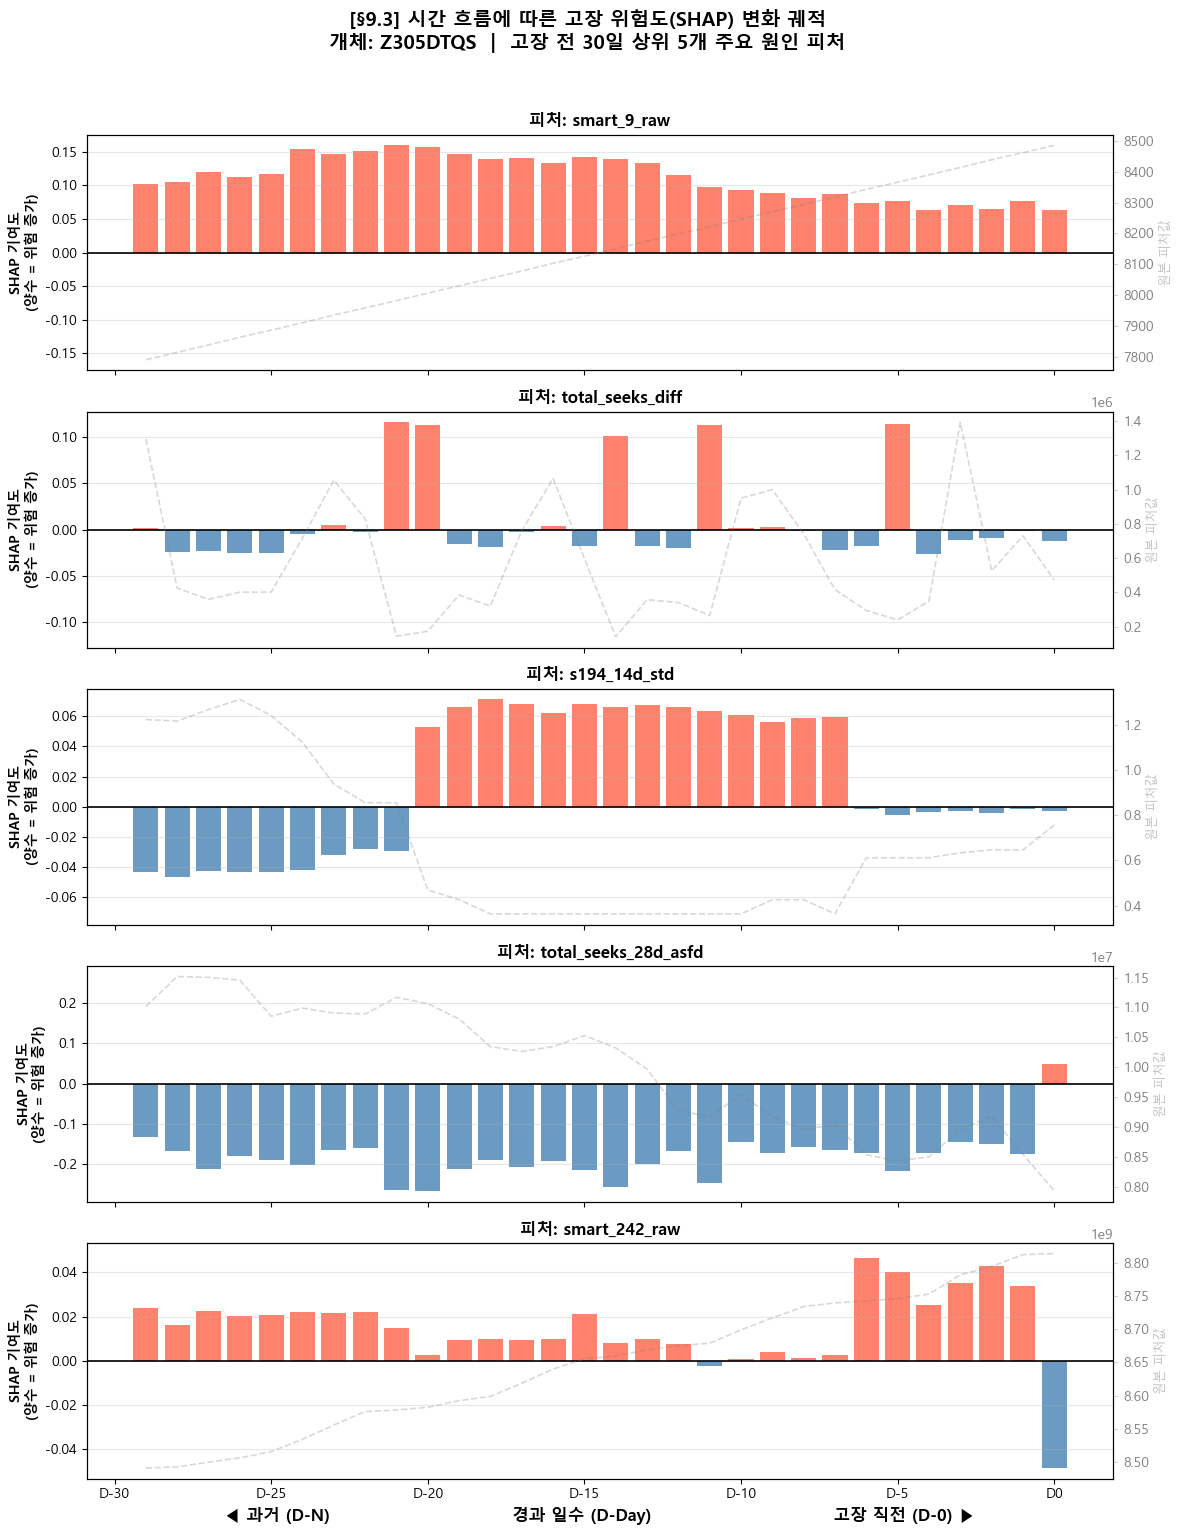


개체 Z305DTQS 분석 완료. 고장 위험을 가장 크게 높인 상위 5개 피처: ['smart_9_raw', 'total_seeks_diff', 's194_14d_std', 'total_seeks_28d_asfd', 'smart_242_raw']


[§9.3] 시간 기반 SHAP Trajectory — 개체: S300ZNVD
       분석 기간: 2016-12-19 ~ 2017-01-17 (30일)


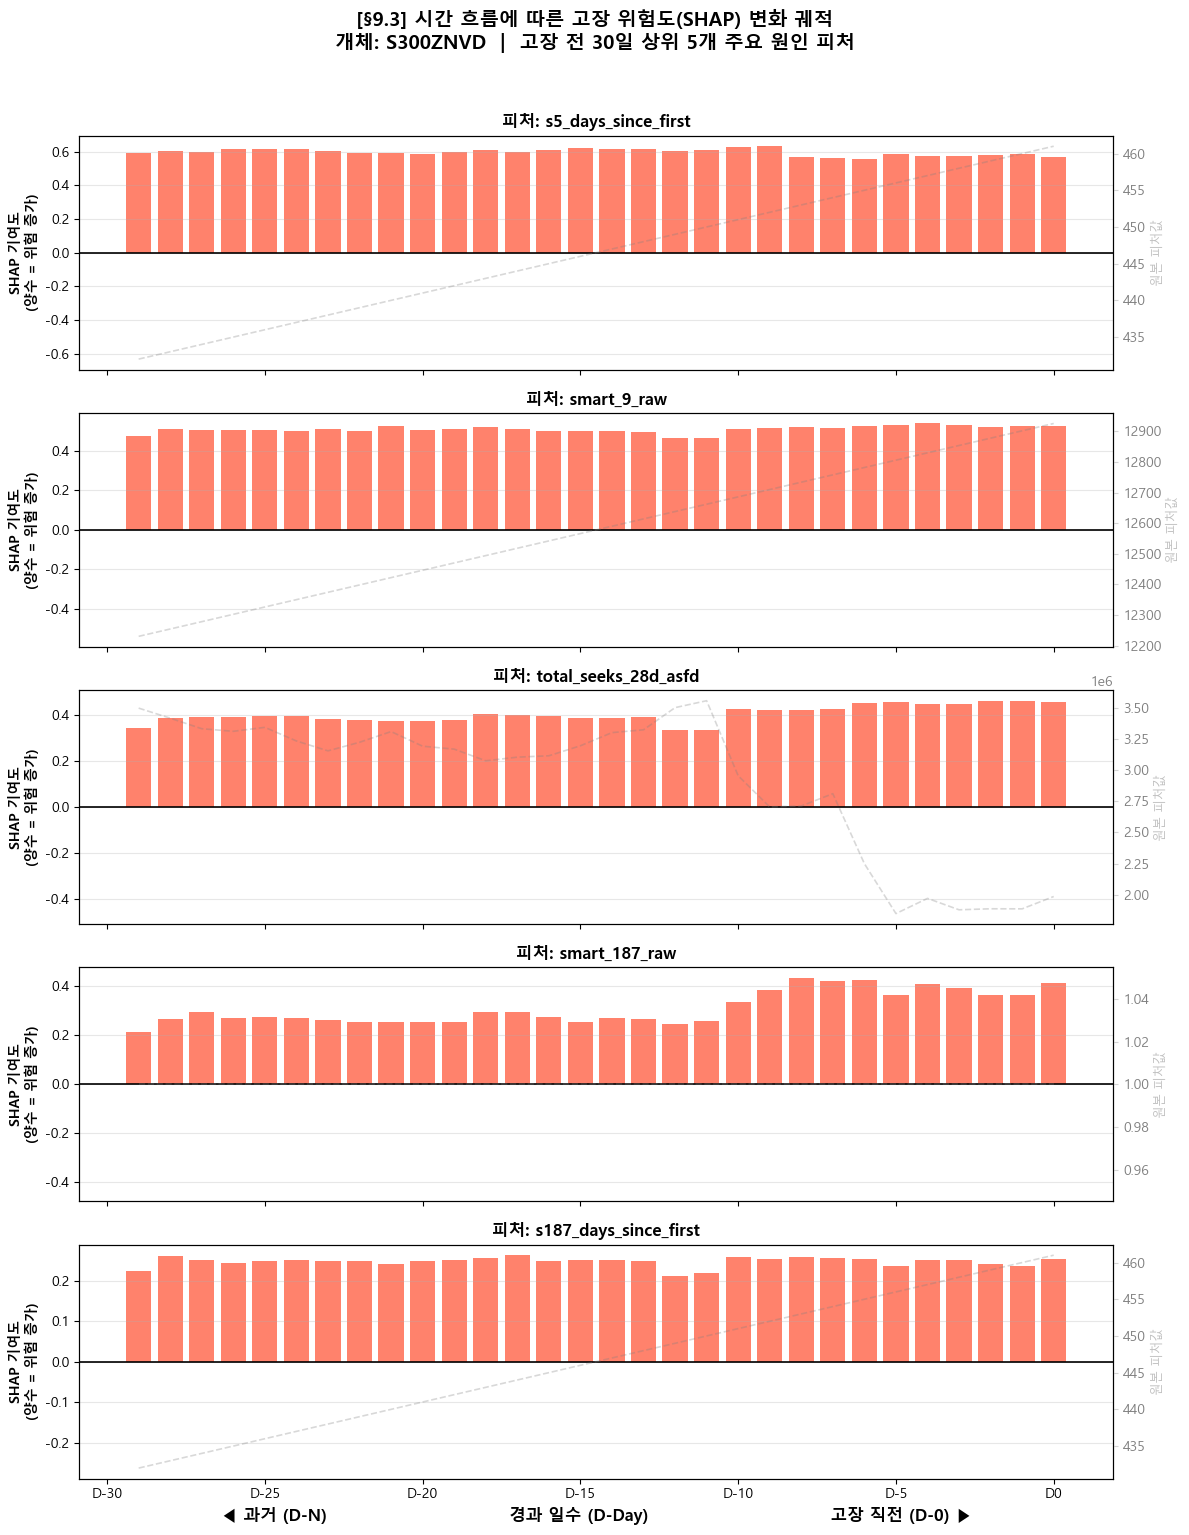


개체 S300ZNVD 분석 완료. 고장 위험을 가장 크게 높인 상위 5개 피처: ['s5_days_since_first', 'smart_9_raw', 'total_seeks_28d_asfd', 'smart_187_raw', 's187_days_since_first']


In [22]:
# §9.3 — 고장 전 N일 창 SHAP Trajectory (각 개체별)
window_days = cfg.TEMPORAL_WINDOW_DAYS
top_n = cfg.TEMPORAL_TOP_N_FEATS

for serial in target_serials:
    df_entity = df_test[df_test[cfg.SERIAL_COL] == serial].sort_values(cfg.DATE_COL)
    last_date = df_entity[cfg.DATE_COL].max()
    start_date = last_date - pd.Timedelta(days=window_days - 1)
    df_window = df_entity[df_entity[cfg.DATE_COL] >= start_date].copy().reset_index(drop=True)
    
    print(f"\n\n" + "="*70)
    print(f"[§9.3] 시간 기반 SHAP Trajectory — 개체: {serial}")
    print(f"       분석 기간: {start_date.date()} ~ {last_date.date()} ({len(df_window)}일)")
    print("="*70)

    if len(df_window) == 0:
        print("⚠️  분석 기간 내 데이터가 없습니다. TEMPORAL_WINDOW_DAYS를 늘려보세요.")
        continue

    X_window = df_window[FEATURE_COLS].reset_index(drop=True)

    # 윈도우 구간 SHAP 계산
    sv_window_list = []
    for model in models:
        exp = shap.TreeExplainer(model)
        sv_w = exp.shap_values(X_window)
        if isinstance(sv_w, list):
            sv_w = sv_w[1]
        sv_window_list.append(sv_w)
    mean_sv_window = np.mean(sv_window_list, axis=0)

    # 양수 방향(위험 증가) 최대값을 기준으로 정렬
    max_pos_window = np.max(mean_sv_window, axis=0) 
    top_feat_idx = np.argsort(max_pos_window)[::-1][:top_n]
    top_feat_names = [FEATURE_COLS[idx] for idx in top_feat_idx]

    dates = df_window[cfg.DATE_COL].values
    days_from_last = [- (last_date - pd.Timestamp(d)).days for d in dates]

    # 시각화
    fig, axes = plt.subplots(top_n, 1, figsize=(12, 3 * top_n), sharex=True)
    if top_n == 1:
        axes = [axes]

    colors = plt.cm.tab10.colors
    for ax, feat_name, feat_idx, color in zip(axes, top_feat_names, top_feat_idx, colors):
        shap_vals = mean_sv_window[:, feat_idx]
        feat_vals = X_window[feat_name].values

        # 원본 피처값 (오른쪽 y축) - 시선 분산을 막기 위해 투명도 약하게 조절
        ax2 = ax.twinx()
        ax2.plot(days_from_last, feat_vals, color="gray", lw=1.2,
                 linestyle="--", label=f"원본값", alpha=0.3)
        ax2.set_ylabel("원본 피처값", color="gray", fontsize=9, alpha=0.5)
        ax2.tick_params(axis="y", labelcolor="gray", colors="lightgray")

        # SHAP 값 (왼쪽 y축)
        bars = ax.bar(days_from_last, shap_vals, 
                      color=["tomato" if v > 0 else "steelblue" for v in shap_vals], 
                      alpha=0.8, width=0.8)
        
        ax.axhline(0, color="black", lw=1.2, ls="-")
        
        max_abs = max(abs(shap_vals.min()), abs(shap_vals.max())) * 1.1
        if max_abs > 0:
            ax.set_ylim(-max_abs, max_abs)
            
        ax.set_ylabel("SHAP 기여도\n(양수 = 위험 증가)", fontsize=10, fontweight="bold")
        ax.set_title(f"피처: {feat_name}", fontsize=12, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)

    # X축 눈금 간격을 5일 단위로 조절
    axes[-1].set_xticks(np.arange(-window_days, 1, 5))
    axes[-1].set_xticklabels([f"D{int(x)}" if x <= 0 else "" for x in axes[-1].get_xticks()])
    axes[-1].set_xlabel("◀ 과거 (D-N)                               경과 일수 (D-Day)                               고장 직전 (D-0) ▶", 
                        fontsize=12, fontweight="bold")

    fig.suptitle(
        f"[§9.3] 시간 흐름에 따른 고장 위험도(SHAP) 변화 궤적\n"
        f"개체: {serial}  |  고장 전 {window_days}일 상위 {top_n}개 주요 원인 피처",
        fontsize=14, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()
    print(f"\n개체 {serial} 분석 완료. 고장 위험을 가장 크게 높인 상위 {top_n}개 피처: {top_feat_names}")


---
## §9.4 실무 활용 요약

본 해석 분석을 통해 도출할 수 있는 실무적 의미를 정리합니다.

In [ ]:
# §9.4 — 실무 활용 요약 출력
SEP = "=" * 65

print(SEP)
print("  §9.4  실무 활용 효과 요약")
print(SEP)

# 상위 피처 목록 (§9.1 결과 기반)
top5_global = shap_rank_df["feature"].head(5).tolist()
print("\n▶ [전역 해석 - §9.1] 주요 고장 기여 피처 Top 5:")
for rank, feat in enumerate(top5_global, 1):
    score = shap_rank_df.loc[shap_rank_df["feature"] == feat, "mean_abs_shap"].values[0]
    print(f"    {rank}. {feat:<35} (Mean |SHAP| = {score:.5f})")

print(f"\n▶ [국소 해석 - §9.2] 분석 개체: {TARGET_SERIAL}")
print(f"    최고 위험 시점: {peak_date}  (예측 확률 = {peak_prob:.4f})")
print(f"    → Waterfall Plot에서 해당 시점의 개별 피처 기여도 확인 가능")

print(f"\n▶ [시간 해석 - §9.3] 고장 전 {window_days}일 창 분석")
print(f"    추적 피처: {', '.join(top_feat_names)}")
print(f"    → 어느 피처가 언제부터 급격히 기여도가 상승했는지 확인 가능")

print(f"\n▶ 실무 의미:")
print(f"    1. 조기 경보 원인 설명: 특정 SMART 지표가 언제부터 이상 신호를 보냈는지 설명")
print(f"    2. 유지보수 판단 근거: 엔지니어에게 '이 디스크는 A 피처 때문에 경보 발령'이라는 근거 제공")
print(f"    3. 모델 신뢰성 향상: Black-box 모델의 의사결정 과정을 투명하게 공개")
print(SEP)